# Model Selection — Companion Notebook

> Companion for `src/my_mlops_project/pipelines/model_selection/`.
> Shows the champion choice, its MLflow registry entry, and the SHAP global
> explainability.

**Purpose:** pick the champion (best validation ROC-AUC), register it in the
MLflow Model Registry (alias `Champion`), and explain it with **SHAP**.

**Inputs:** `trained_models.pkl`, `training_metrics.json`.
**Outputs:** `champion_model.pkl`, `champion_info.json`, `shap_summary.png`, MLflow registry entry.

## Table of Contents
1. [Setup](#1-setup)
2. [The champion](#2-the-champion)
3. [SHAP explainability](#3-shap-explainability)
4. [The MLflow registry entry](#4-the-mlflow-registry-entry)
5. [Notes for the report](#5-notes-for-the-report)

## 1. Setup

In [1]:
import os, sys, json
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)                 # so sqlite:///mlflow.db resolves
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA = PROJECT_ROOT / "data"
print("working dir:", Path.cwd().name)

working dir: Project


## 2. The champion

The family with the best validation ROC-AUC, chosen and registered by the pipeline.

In [2]:
champion_info = json.load(open(DATA / "08_reporting" / "champion_info.json"))
print("champion family :", champion_info["champion_family"])
print("primary metric  :", champion_info["primary_metric"], "=", round(champion_info["value"], 4))
print("ranking         :", champion_info["ranking"])
print("registry        :", champion_info.get("registered_model_name"),
      "v" + str(champion_info.get("registered_version")), "/", champion_info.get("alias"))

champion family : GradientBoosting
primary metric  : roc_auc = 0.801
ranking         : ['GradientBoosting', 'RandomForest', 'LogisticRegression']
registry        : credit_default_champion v2 / Champion


## 3. SHAP explainability

The global SHAP summary shows which features drive the champion's predictions and
in which direction. For credit default we expect the recent repayment-status
features (`PAY_0`, `pay_delay_max`) to dominate — intuitive and defensible.

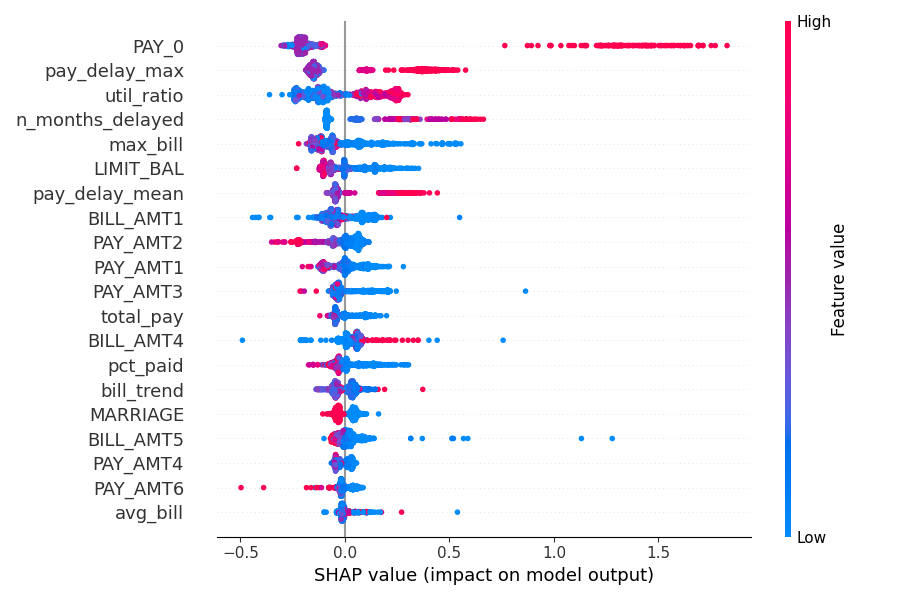

In [3]:
from IPython.display import Image
Image(filename=str(DATA / "08_reporting" / "shap_summary.png"))

In [4]:
# A quick text ranking from the model's own feature importances (complements SHAP).
import pickle
champion = pickle.load(open(DATA / "06_models" / "champion_model.pkl", "rb"))
X_train = pd.read_parquet(DATA / "05_model_input" / "X_train.parquet")
if hasattr(champion, "feature_importances_"):
    imp = pd.Series(champion.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print("Top 10 features by model importance:")
    print(imp.head(10).round(4).to_string())

Top 10 features by model importance:
PAY_0               0.5187
pay_delay_max       0.0980
n_months_delayed    0.0890
pay_delay_mean      0.0527
max_bill            0.0282
util_ratio          0.0220
total_pay           0.0182
LIMIT_BAL           0.0175
BILL_AMT1           0.0171
avg_bill            0.0147


## 4. The MLflow registry entry

The champion is registered with the `Champion` alias — this is what the FastAPI
service (`model_predict`) loads at startup, and how you'd roll back (re-point the
alias) if a challenger underperforms.

In [5]:
import mlflow
from mlflow import MlflowClient
mlflow.set_tracking_uri("sqlite:///mlflow.db")
try:
    client = MlflowClient()
    mv = client.get_model_version_by_alias("credit_default_champion", "Champion")
    print(f"Registered model: {mv.name}")
    print(f"Champion version: v{mv.version}")
    print(f"Backing run id  : {mv.run_id}")
except Exception as e:
    print("registry query skipped:", type(e).__name__, "-", str(e)[:120])

Registered model: credit_default_champion
Champion version: v2
Backing run id  : 98367d9e898c424a9e1c1fff17fea0bd


## 5. Notes for the report

> For [`../report/REPORT_OUTLINE.md`](../report/REPORT_OUTLINE.md) §3 (results / explainability).

- **Champion selection** is automated: the best validation ROC-AUC family wins
  (Gradient Boosting here), and is **registered in the MLflow Model Registry**
  with a `Champion` alias — the production hand-off + rollback mechanism.
- **SHAP global summary** (`shap_summary.png`) is the required explainability
  artifact: it shows *which* features drive default risk and *which direction* —
  the repayment-status features lead, which matches credit-risk intuition.
- This champion is what the serving layer (`model_predict`) loads from the
  registry at startup.